# In-Depth: Decision Trees and Random Forests

Random forest classification is a type of *ensemble* method, one that relies on aggregating the results of simple estimators.

In the case of random forest classification, the simple estimators are decision trees.

## Motivating Random Forests: Decision Trees

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

(np.float64(-4.61333927473542),
 np.float64(4.786447242633593),
 np.float64(-2.481071236072416),
 np.float64(10.854055834769047))

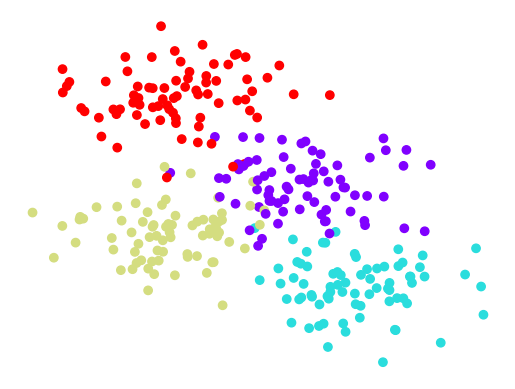

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
# X has 2 features, and y consists of 4 classes

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='rainbow')
plt.axis('off')

1. Choose the best feature to be the root node based on metrics: e.g., gini impurity
2. Select the next best feature to be the next set of nodes
3. Repeat until all nodes are pure.

Basically, you just keep on asking questions until you narrow it down to a particular class.

In [3]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X,y)

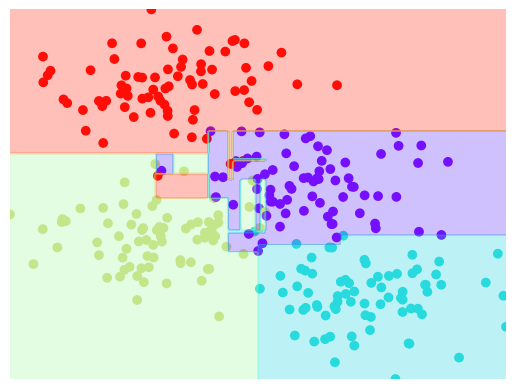

In [4]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)
Z = tree.predict(np.column_stack([xx.ravel(), yy.ravel().T])).reshape(xx.shape)
n_classes = len(np.unique(y))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='rainbow')
plt.contourf(xx, yy, Z, cmap='rainbow', alpha=0.3)
plt.axis('off');

At higher depths, we get strangely shaped regions. It appears to be modelling the points one-by-one instead of providing one region for each class. This is an indication of **overfitting**.

A workaround is to consider training multiple decision trees on different samples of the dataset and aggregating the results.

This is what ensemble methods are all about.

## Ensembles of Estimators: Random Forests

Procedure for creating a random forest:
1. Create a bootsrap sample of the dataset (resample with replacement)
2. Create a decision tree out of the bootstrap sample except only choosing a randomly selected subset of features at each depth.
3. Repeat Steps 1 and 2 as desired
4. Aggregate the results of the decision trees.

The 'Random' in random forest means creating multiple decision trees out of randomly selected samples and randomly selected features.

Each bootstrap sample may not contain all of the samples in the dataset; such samples are called **out-of-bat** samples. The accuracy of a random forest can be measured from how good it is at correctly predicting out-of-bag samples.

The accuracy of a random forest also changes according to the size of the randomly selected subset of features (in step 2) (how many randomly selected features were used in each depth in each decision tree). 

The random forest with the highest accuracy is **The Random Forest** -- this is the estimator that is returned when we use Scikit learn's `RandomForestClassifier()`. Scikit learn does the job of finding the optimized ensemble of decision trees.

In [5]:
def visualize_classifier(model, X, y, cmap='rainbow'):
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min(), X[:,0].max(), 200),
        np.linspace(X[:,1].min(), X[:,1].max(), 200)
    )
    
    Z = model.predict(np.column_stack([xx.ravel(), yy.ravel().T])).reshape(xx.shape)
    
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap)
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    plt.axis('off');

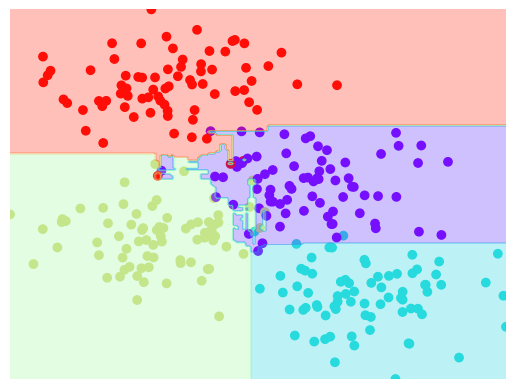

In [6]:
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(
    tree, n_estimators=100, max_samples=0.8, random_state=1
)
bag.fit(X,y)
visualize_classifier(bag, X, y)

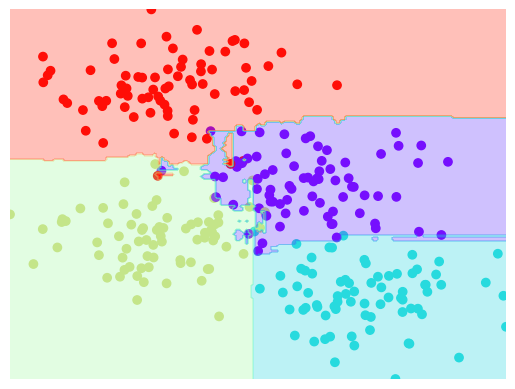

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X,y)
visualize_classifier(model, X, y)

## Random Forest Regression
We can also use Random Forests for regression.

Good for non-linear data

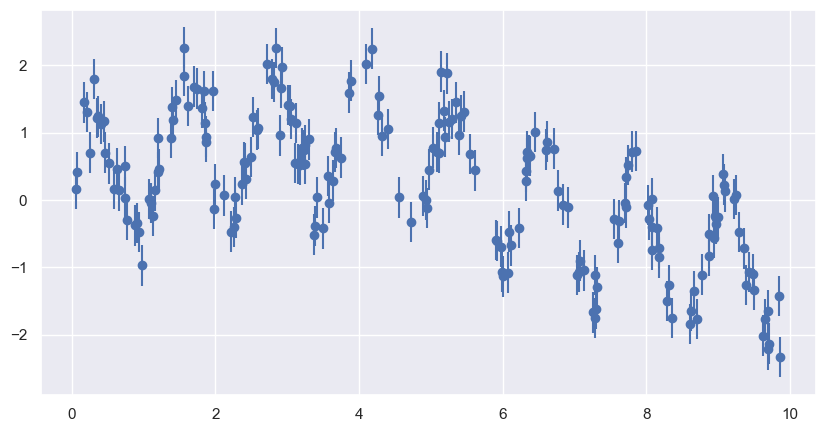

In [31]:
# Create data - copied from book
rng = np.random.RandomState(42)
X = 10 * rng.rand(200)
def func(X, sigma=0.3):
    fast_oscillation = np.sin(5 * X)
    slow_oscillation = np.sin(0.5 * X)
    noise = sigma * rng.randn(len(X))
    return slow_oscillation + fast_oscillation + noise
    
y = func(X)
plt.figure(figsize=(10,5))
plt.errorbar(X, y, 0.3, fmt='o');

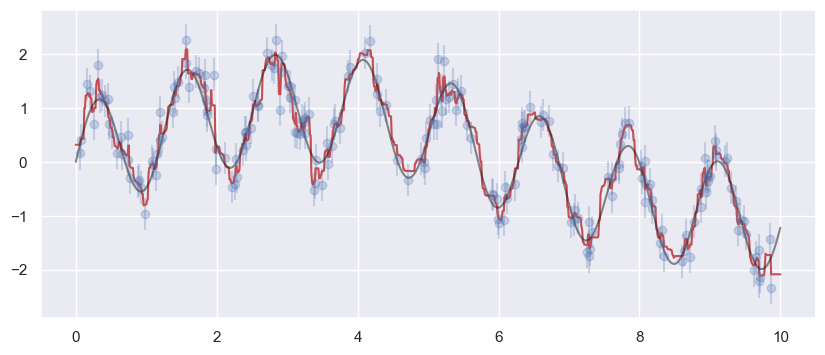

In [60]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 200)
model.fit(X[:,np.newaxis],y)

X_test = np.linspace(0,10,1000)
ypred = model.predict(X_test[:,np.newaxis])
plt.figure(figsize=(10,4))
plt.errorbar(X,y,0.3,fmt='o', alpha=0.25)
plt.plot(X_test, ypred, '-r')
plt.plot(X_test, func(X_test, sigma=0), '-k', alpha=0.5);

### Review: Visualizing a Three-Dimensional Function -- Contour plots

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]], shape=(40, 50))

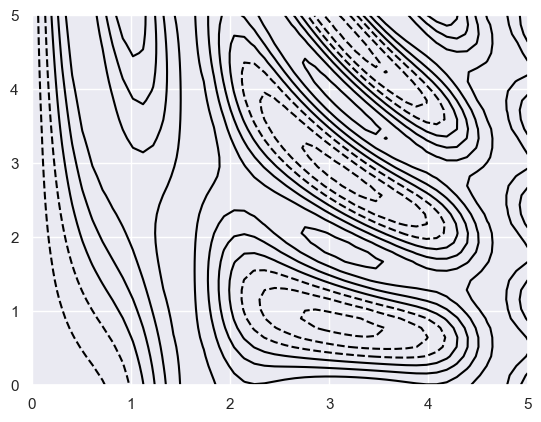

In [85]:
def f(x,y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x,y)
Z = f(X,Y)

plt.contour(X, Y, Z, colors='black');
Z

In [86]:
Z

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]], shape=(40, 50))

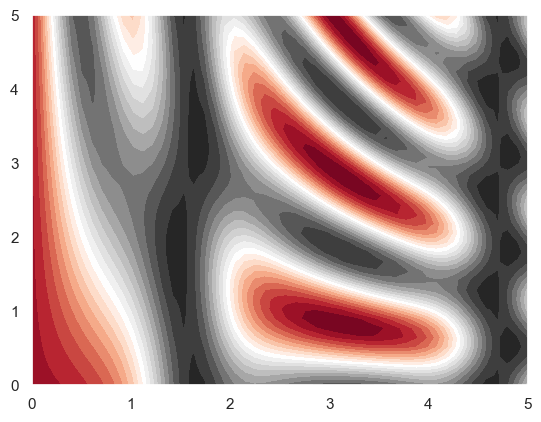

In [49]:
plt.contourf(X, Y, Z, 20, cmap='RdGy');